In [1]:
import model_loader
import pipeline
from PIL import Image
from transformers import CLIPTokenizer
import torch

DEVICE = 'cpu'
ALLOW_CUDA = False
ALLOW_MPS = True

if torch.cuda.is_available() and ALLOW_CUDA:
    DEVICE = 'cuda'

elif torch.backends.mps.is_available() and ALLOW_MPS:
    DEVICE = 'mps'
    
print(f'{DEVICE = }')

/opt/miniconda3/envs/selfmade-diffusion/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE = 'mps'


In [2]:

tokenizer = CLIPTokenizer('../data/vocab.json', '../data/merges.txt')
model_file = '../data/v1-5-pruned-emaonly.ckpt'
models = model_loader.preload_models_from_standart_weights(model_file, DEVICE)


100%|██████████| 50/50 [01:05<00:00,  1.31s/it]


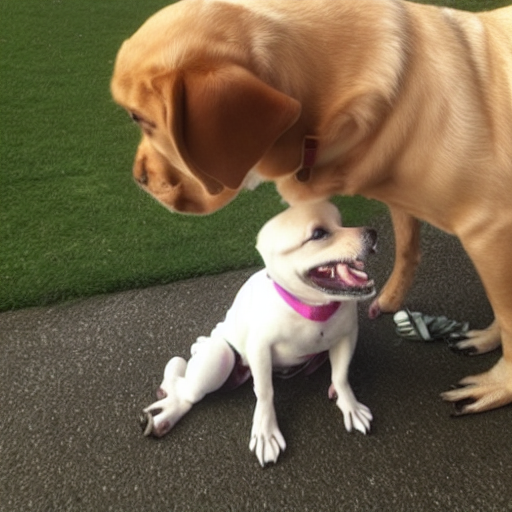

In [3]:
# text to img
prompt = 'a dog and a frog'
uncond_prompt = ''
do_cfg = True
cfg_scale = 6.7

n_inference_steps = 50
seed = 67

output_image = pipeline.generate(
    prompt=prompt, 
    do_cfg=do_cfg, 
    cfg_scale=cfg_scale, 
    n_inference_steps=n_inference_steps, 
    seed=seed,
    models=models, 
    device=DEVICE, 
    idle_device='cpu', 
    tokenizer=tokenizer,
    uncond_prompt=uncond_prompt,
    
    # input_image=inp
    # strength=
    # sampler_name=
)

Image.fromarray(output_image)

100%|██████████| 25/25 [00:49<00:00,  1.97s/it]


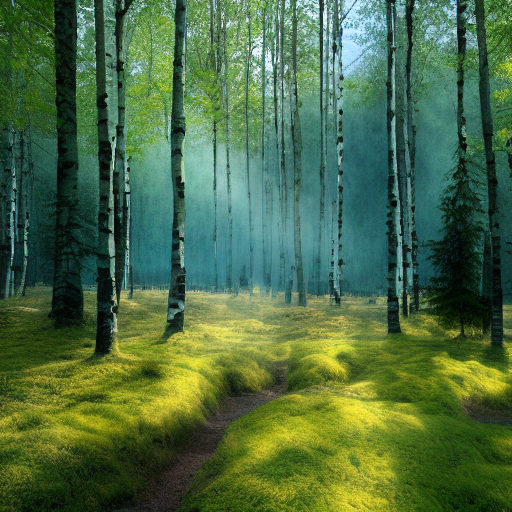

In [ ]:
# img to img
prompt = 'birch forest'
uncond_prompt = ''
do_cfg = True
cfg_scale = 6.7

n_inference_steps = 50
seed = 67

input_image = None
image_path = '../images/img.png'
input_image = Image.open(image_path)
strength = 0.5 # 1 - no attention on img, 0 - no diffusion process

sampler = "ddpm"

output_image = pipeline.generate(
    prompt=prompt, 
    do_cfg=do_cfg, 
    cfg_scale=cfg_scale, 
    n_inference_steps=n_inference_steps, 
    seed=seed,
    models=models, 
    device=DEVICE, 
    idle_device='cpu', 
    tokenizer=tokenizer,
    uncond_prompt=uncond_prompt,
    
    input_image=input_image,
    strength=strength,
    sampler_name=sampler
)

Image.fromarray(output_image)